# CSE457 - XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
## LAB 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ
**Sinh viên:** Nguyễn Văn Minh | **MSSV:** 2351260673
---
## Khối A: Đọc, kiểm tra dữ liệu và trực quan hóa chuỗi âm thanh ban đầu

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pydub import AudioSegment

# 1. Hàm nạp và chuẩn hóa âm thanh về [-1.0, 1.0]
def load_audio(filepath):
    audio = AudioSegment.from_file(filepath)
    mono = audio.set_channels(1)
    samples = np.array(mono.get_array_of_samples(), dtype=np.float64)
    x = samples / float(2 ** (8 * mono.sample_width - 1))
    return audio, x, audio.frame_rate

# 2. Nạp dữ liệu âm nhạc (Piano) và tiếng nói (Speech)
audio_piano, x_piano, Fs_piano = load_audio(os.path.join("audio", "piano_sample.mp3"))
audio_speech, x_speech, Fs_speech = load_audio(os.path.join("audio", "news_speech.mp3"))

# 3. Bảng tổng hợp thông số và đo đạc Peak, RMS
def get_stats(label, audio, x, fpath):
    dur = len(audio) / 1000.0
    fsize = os.path.getsize(fpath)
    peak = float(np.max(np.abs(x)))
    rms = float(np.sqrt(np.mean(x ** 2)))
    return {
        "Tệp dữ liệu": label,
        "Sampling Rate (Fs)": f"{audio.frame_rate:,} Hz",
        "Số kênh": f"{audio.channels} (Stereo)",
        "Thời lượng": f"{dur:.3f} s",
        "Dung lượng": f"{fsize/1024:.1f} KB",
        "Bit rate MP3": f"{(fsize*8)/(dur*1000):.1f} kbps",
        "Peak": round(peak, 4),
        "Peak (dBFS)": round(20 * np.log10(peak), 2),
        "RMS": round(rms, 4),
        "RMS (dBFS)": round(20 * np.log10(rms), 2)
    }

df_summary = pd.DataFrame([
    get_stats("Piano (Âm nhạc)", audio_piano, x_piano, os.path.join("audio", "piano_sample.mp3")),
    get_stats("Speech (Bản tin)", audio_speech, x_speech, os.path.join("audio", "news_speech.mp3"))
])
display(df_summary)


,Tệp dữ liệu,Sampling Rate (Fs),Số kênh,Thời lượng,Dung lượng,Bit rate MP3,Peak,Peak (dBFS),RMS,RMS (dBFS)
0,Piano (Âm nhạc),"48,000 Hz",2 (Stereo),35.243 s,834.8 KB,194.0 kbps,0.4420,-7.09,0.0653,-23.70
1,Speech (Bản tin),"48,000 Hz",2 (Stereo),35.243 s,834.6 KB,194.0 kbps,0.4571,-6.80,0.0658,-23.64


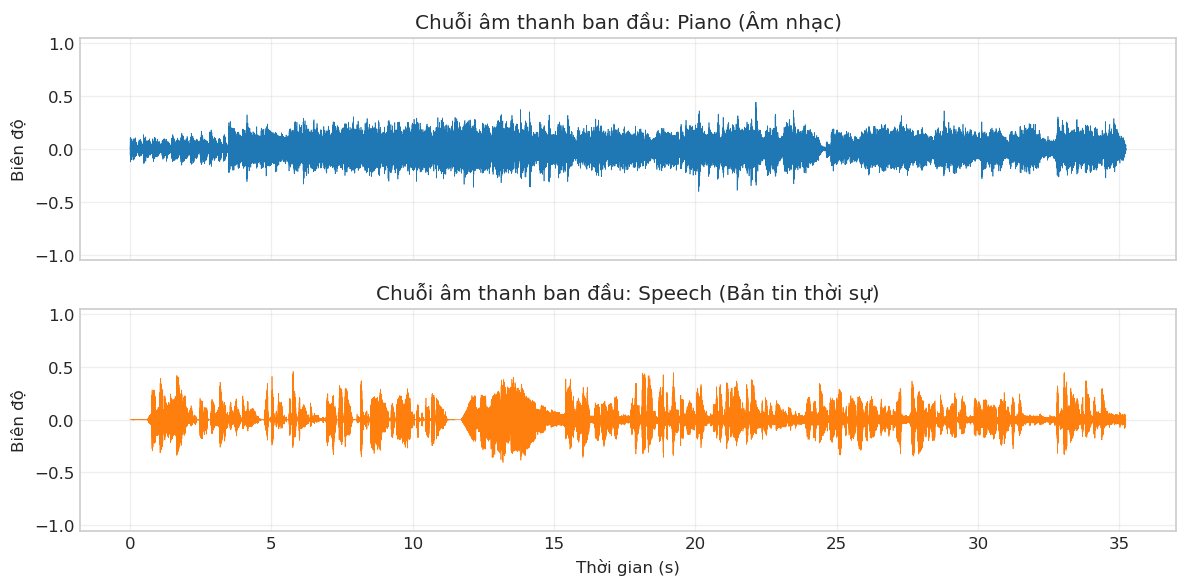

In [6]:
# Trực quan hóa chuỗi âm thanh ban đầu (Visualize trực tiếp, không lưu file)
t_piano = np.arange(len(x_piano)) / Fs_piano
t_speech = np.arange(len(x_speech)) / Fs_speech

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_piano, x_piano, lw=0.4, color="tab:blue")
axes[0].set_title("Chuỗi âm thanh ban đầu: Piano (Âm nhạc)")
axes[0].set_ylabel("Biên độ")
axes[0].set_ylim([-1.05, 1.05])
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_speech, x_speech, lw=0.4, color="tab:orange")
axes[1].set_title("Chuỗi âm thanh ban đầu: Speech (Bản tin thời sự)")
axes[1].set_xlabel("Thời gian (s)")
axes[1].set_ylabel("Biên độ")
axes[1].set_ylim([-1.05, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Nhận xét kỹ thuật Khối A:
1. **Tần số lấy mẫu:** Cả 2 tệp đều có $F_s = 48{,}000\text{ Hz}$, tần số Nyquist tương ứng là $F_N = 24{,}000\text{ Hz}$, đảm bảo bao quát toàn bộ dải nghe của tai người ($20\text{ Hz} - 20\text{ kHz}$) mà không bị chồng phổ (aliasing).
2. **Đặc trưng dạng sóng ban đầu:** Tín hiệu Piano có dạng sóng dao động liên tục với các dải ngân hài âm kéo dài; trong khi tín hiệu Tiếng nói thời sự thể hiện các xung phát âm gián đoạn rõ rệt, gồm các cụm nguyên âm/phụ âm đan xen với các khoảng lặng tự nhiên giữa các câu từ.
3. **Kiểm tra clipping:** Giá trị đỉnh của cả hai tín hiệu đều nằm dưới ngưỡng bão hòa $1.0$ (Piano: $\text{Peak} = 0.4420$, Speech: $\text{Peak} = 0.4571$), xác nhận cả 2 tệp dữ liệu đều hoàn toàn sạch và không bị xén biên (clipping).